Transient Change Detection

In [ ]:
!pip uninstall tensorflow

In [ ]:
!pip install tensorflow-gpu==2.0.0-alpha0

     |████████████████████████████████| 332.1MB 44kB/s 
     |████████████████████████████████| 419kB 53.7MB/s 
     |████████████████████████████████| 3.0MB 55.6MB/s 


In [ ]:
import tensorflow as tf
print(tf.__version__)

2.0.0-alpha0


In [ ]:
from __future__ import absolute_import, division, print_function, unicode_literals

import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.layers import Input, LSTM, Dense, Reshape

In [ ]:
input_dim = 1 # input dimensionality
mu_pre = 0
mu_post = 1

In [ ]:
def window_dec_stat(obs_window):
    result = 0
    for i in range(len(obs_window)):
        result = max(0, result + obs_window[i] - mu_post/2)
    return result

In [ ]:
batch_size = 32
num_batch = 100
data_size = batch_size * num_batch
timesteps = 3000
rho1 = 0.001 
rho2 = 0.002

x_train = []
y_train = []
for jj in range(data_size):
    tau1 = np.random.geometric(rho1) # random change-point for the transient change
    tau2 = tau1 + np.random.geometric(rho2) # time to return back to the pre-change case
    t = 0
    data_i = np.zeros([1,timesteps,input_dim]) 
    label_i = np.zeros([1,timesteps,1]) 
    while t < timesteps:
        if t < tau1:
            data_i[0][t] = mu_pre + np.random.randn()  # pre-change observation
            label_i[0][t] = 0.0  # pre-label   
        elif t < tau2:
            data_i[0][t] = mu_post + np.random.randn()  # post-change observation
            label_i[0][t] = 1.0  # post-label  
        else:
            data_i[0][t] = mu_pre + np.random.randn()  # pre-change observation
            label_i[0][t] = 0.0  # pre-label
        t += 1

    if x_train == []:
        x_train = data_i
    else:    
        x_train = np.concatenate((x_train,data_i),axis=0)

    if y_train == []:
        y_train = label_i 
    else:
        y_train = np.concatenate((y_train,label_i),axis=0)

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:28: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:33: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.


In [ ]:
print(x_train.shape)
print(y_train.shape)

(3200, 3000, 1)
(3200, 3000, 1)


In [ ]:
val_size = 500
rho1 = 0.002 
rho2 = 0.001

x_val = []
y_val = []
for jj in range(val_size):
    tau1 = np.random.geometric(rho1) 
    tau2 = tau1 + np.random.geometric(rho2) 
    t = 0
    data_i = np.zeros([1,timesteps,input_dim]) 
    label_i = np.zeros([1,timesteps,1]) 
    while t < timesteps:
        if t < tau1:
            data_i[0][t] = mu_pre + np.random.randn()  # pre-change observation
            label_i[0][t] = 0.0  # pre-label   
        elif t < tau2:
            data_i[0][t] = mu_post + np.random.randn()  # post-change observation
            label_i[0][t] = 1.0  # post-label  
        else:
            data_i[0][t] = mu_pre + np.random.randn()  # pre-change observation
            label_i[0][t] = 0.0  # pre-label
        t += 1

    if x_val == []:
        x_val = data_i
    else:    
        x_val = np.concatenate((x_val,data_i),axis=0)

    if y_val == []:
        y_val = label_i 
    else:
        y_val = np.concatenate((y_val,label_i),axis=0)


/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:25: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:30: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.


In [ ]:
print(x_val.shape) 
print(y_val.shape)

(500, 3000, 1)
(500, 3000, 1)


In [ ]:
model = tf.keras.Sequential() 
model.add(Input(shape=(timesteps,input_dim))) 
model.add(LSTM(16, return_sequences = True))  
model.add(Dense(10, activation='relu')) 
model.add(Dense(1, activation='sigmoid'))
model.summary() 

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
unified_lstm (UnifiedLSTM)   (None, 3000, 16)          1152      
_________________________________________________________________
dense (Dense)                (None, 3000, 10)          170       
_________________________________________________________________
dense_1 (Dense)              (None, 3000, 1)           11        
Total params: 1,333
Trainable params: 1,333
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(x_train, y_train,
          validation_data=(x_val, y_val),
          batch_size=batch_size,
          epochs=20)

Train on 3200 samples, validate on 500 samples
Epoch 1/20
3200/3200 [==============================] - 16s 5ms/sample - loss: 0.2832 - accuracy: 0.9385 - val_loss: 0.0997 - val_accuracy: 0.9873
Epoch 2/20
3200/3200 [==============================] - 10s 3ms/sample - loss: 0.0509 - accuracy: 0.9884 - val_loss: 0.0466 - val_accuracy: 0.9896
Epoch 3/20
3200/3200 [==============================] - 10s 3ms/sample - loss: 0.0372 - accuracy: 0.9905 - val_loss: 0.0390 - val_accuracy: 0.9902
Epoch 4/20
3200/3200 [==============================] - 10s 3ms/sample - loss: 0.0345 - accuracy: 0.9909 - val_loss: 0.0369 - val_accuracy: 0.9904
Epoch 5/20
3200/3200 [==============================] - 10s 3ms/sample - loss: 0.0336 - accuracy: 0.9910 - val_loss: 0.0370 - val_accuracy: 0.9904
Epoch 6/20
3200/3200 [==============================] - 10s 3ms/sample - loss: 0.0332 - accuracy: 0.9911 - val_loss: 0.0360 - val_accuracy: 0.9905
Epoch 7/20
3200/3200 [==============================] - 10s 3ms/sample 

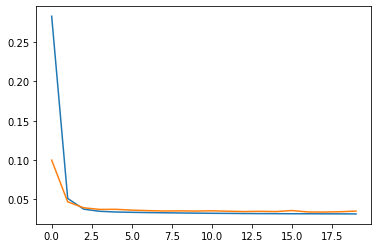

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [ ]:
model2 = tf.keras.Sequential()  # model2 has the same structure and weights with the trained network  
model2.add(Input(shape=(1,input_dim), batch_size=1)) # only difference is it takes single input a time, as usual in online stream processing
model2.add(LSTM(16, return_sequences = True, stateful=True))  # we have an explicit control on the internal RNN state: the RNN state is going to be reset for each new data stream       
model2.add(Dense(10, activation='relu')) 
model2.add(Dense(1, activation='sigmoid')) 
model2.summary() 

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
unified_lstm_1 (UnifiedLSTM) (1, 1, 16)                1152      
_________________________________________________________________
dense_2 (Dense)              (1, 1, 10)                170       
_________________________________________________________________
dense_3 (Dense)              (1, 1, 1)                 11        
Total params: 1,333
Trainable params: 1,333
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model2.set_weights(model.get_weights()) 

**Performance Evaluation** 

Experiment 1: tau1 = 1000, K = 25

In [ ]:
# Performance Evaluation (Data-Driven QCD Procedure) 
test_size = 10000 # number of experiments  
h_vec = np.linspace(0.01,0.99,50) # test thresholds
num_false_alarm_events = np.zeros(len(h_vec)) # number of false alarm events at each threshold over all experiments 
num_missed_events = np.zeros(len(h_vec)) # number of missed detection events at each threshold over all experiments 
tau1 = 1000 # change-point
K = 25 # transient change duration
tau2 = tau1 + K
for jj in range(test_size):
    if jj % 200 == 0:
        print(jj)
    # initialization for a new experiment
    t = 0 # time  
    model2.reset_states() # reset the internal RNN state for the new experiment
    alarm_flag_vec = np.zeros(len(h_vec)) # alarm flags 
    # new experiment
    while t <= tau2:
        t += 1
        # observation at time t
        if t < tau1:
            data_t = mu_pre + np.random.randn(1,1,input_dim)  # pre-change observation
        elif t < tau2:
            data_t = mu_post + np.random.randn(1,1,input_dim)  # post-change observation
        else:
            data_t = mu_pre + np.random.randn(1,1,input_dim)  # pre-change observation
        # decision statistic of the data-driven procedure
        dec_stat = model2.predict(data_t) 
        dec_stat = dec_stat[0][0][0]
        # update the alarm flags, the false alarm events, and the detection delays
        if t < tau1:
            num_false_alarm_events += (alarm_flag_vec == 0)*(dec_stat >= h_vec)
            alarm_flag_vec += (alarm_flag_vec == 0)*(dec_stat >= h_vec) 
        elif t < tau2:
            alarm_flag_vec += (alarm_flag_vec == 0)*(dec_stat >= h_vec)
        elif t == tau2:
            num_missed_events += (1 - alarm_flag_vec)
            
# compute the probability of false alarm (pfa), missed detection ratio (mdr), and conditional average detection delay (add) over all experiments
pfa_vec = num_false_alarm_events/test_size
mdr_vec = num_missed_events/test_size

In [ ]:
pfa_vec 

array([1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00,
       1.000e+00, 1.000e+00, 1.000e+00, 9.997e-01, 9.947e-01, 9.721e-01,
       9.223e-01, 8.272e-01, 7.048e-01, 5.733e-01, 4.778e-01, 4.233e-01,
       3.813e-01, 3.396e-01, 3.056e-01, 2.762e-01, 2.463e-01, 2.212e-01,
       2.010e-01, 1.824e-01, 1.627e-01, 1.482e-01, 1.313e-01, 1.185e-01,
       1.071e-01, 9.430e-02, 8.630e-02, 7.790e-02, 7.110e-02, 6.350e-02,
       5.720e-02, 5.040e-02, 4.440e-02, 4.000e-02, 3.480e-02, 2.930e-02,
       2.490e-02, 2.070e-02, 1.600e-02, 1.270e-02, 1.000e-02, 7.000e-03,
       3.300e-03, 7.000e-04])

In [ ]:
mdr_vec 

array([0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e-04, 9.000e-04,
       2.100e-03, 5.500e-03, 9.300e-03, 1.400e-02, 1.970e-02, 2.260e-02,
       2.580e-02, 2.780e-02, 3.110e-02, 3.310e-02, 3.580e-02, 3.880e-02,
       4.190e-02, 4.440e-02, 4.770e-02, 4.970e-02, 5.150e-02, 5.450e-02,
       5.780e-02, 6.110e-02, 6.400e-02, 6.780e-02, 7.170e-02, 7.590e-02,
       8.080e-02, 8.510e-02, 8.990e-02, 9.570e-02, 1.025e-01, 1.100e-01,
       1.183e-01, 1.285e-01, 1.405e-01, 1.541e-01, 1.723e-01, 2.040e-01,
       2.505e-01, 3.931e-01])

In [ ]:
# Benchmark: Window-limited CUSUM
test_size = 10000 # number of experiments  
h_vec = np.linspace(0.2,20,50) # test thresholds 
wlc_false_alarm_events = np.zeros(len(h_vec)) # number of false alarm events at each threshold over all experiments 
wlc_missed_events = np.zeros(len(h_vec)) # number of missed detection events at each threshold over all experiments 
tau1 = 1000 # change-point
K = 25 # transient change duration
tau2 = tau1 + K
for jj in range(test_size):
    if jj % 1000 == 0:
        print(jj)
    # initialization for a new experiment
    t = 0 # time  
    wlc_flag_vec = np.zeros(len(h_vec)) # alarm flags 
    # initial observation window (initial state)
    obs_window = []
    for i in range(K):
        obs_window.append(mu_pre + np.random.randn())   
    # new experiment
    while t <= tau2:
        t += 1
        # observation at time t
        if t < tau1:
            data_t = mu_pre + np.random.randn()  # pre-change observation
        elif t < tau2:
            data_t = mu_post + np.random.randn()  # post-change observation
        else:
            data_t = mu_pre + np.random.randn()  # pre-change observation
        # update the state (observation window)
        obs_window.append(data_t)
        obs_window = obs_window[1:] 
        # compute the decision statistic
        g = window_dec_stat(obs_window)
        # update the alarm flags, the false alarm events, and the detection delays
        if t < tau1:
            wlc_false_alarm_events += (wlc_flag_vec == 0)*(g >= h_vec)
            wlc_flag_vec += (wlc_flag_vec == 0)*(g >= h_vec) 
        elif t < tau2:
            wlc_flag_vec += (wlc_flag_vec == 0)*(g >= h_vec)
        elif t == tau2:
            wlc_missed_events += (1 - wlc_flag_vec)
            
# compute the probability of false alarm (pfa), missed detection ratio (mdr), and conditional average detection delay (add) over all experiments
wlc_pfa_vec = wlc_false_alarm_events/test_size
wlc_mdr_vec = wlc_missed_events/test_size

In [ ]:
wlc_pfa_vec 

array([1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00,
       1.000e+00, 9.996e-01, 9.957e-01, 9.751e-01, 9.058e-01, 7.856e-01,
       6.431e-01, 4.896e-01, 3.603e-01, 2.584e-01, 1.761e-01, 1.224e-01,
       8.400e-02, 5.760e-02, 3.940e-02, 2.670e-02, 1.960e-02, 1.340e-02,
       9.000e-03, 5.900e-03, 4.100e-03, 2.500e-03, 1.300e-03, 1.000e-03,
       6.000e-04, 3.000e-04, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00])

In [ ]:
wlc_mdr_vec

array([0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 1.000e-04, 8.000e-04, 2.900e-03,
       6.900e-03, 1.200e-02, 2.070e-02, 3.200e-02, 4.420e-02, 5.810e-02,
       7.370e-02, 9.170e-02, 1.108e-01, 1.314e-01, 1.543e-01, 1.766e-01,
       2.033e-01, 2.318e-01, 2.612e-01, 2.914e-01, 3.232e-01, 3.555e-01,
       3.898e-01, 4.256e-01, 4.599e-01, 4.955e-01, 5.310e-01, 5.654e-01,
       6.017e-01, 6.340e-01, 6.648e-01, 6.970e-01, 7.264e-01, 7.561e-01,
       7.859e-01, 8.093e-01, 8.322e-01, 8.533e-01, 8.700e-01, 8.888e-01,
       9.049e-01, 9.173e-01])

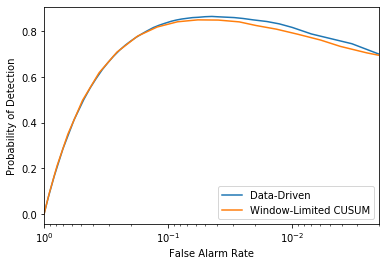

In [ ]:
plt.plot(pfa_vec,1-mdr_vec-pfa_vec)
plt.plot(wlc_pfa_vec,1-wlc_mdr_vec-wlc_pfa_vec)
plt.xlim(1, 0.002) 
plt.xscale('log')
plt.xlabel('False Alarm Rate')
plt.ylabel('Probability of Detection') 
plt.legend(["Data-Driven","Window-Limited CUSUM"])  

Experiment 2: Detect the change from f_1 to f_0

FAP Calculations

In [ ]:
# Data-Driven QCD Procedure 
test_size = 1000 # number of experiments 
h_vec = np.linspace(0.995,0.04,50) # test thresholds 
total_false_alarm_periods = np.zeros(len(h_vec)) # sum of the false alarm periods at each threshold over all experiments
for jj in range(test_size):
    if jj % 10 == 0:
        print(jj)
    # initialization for a new experiment
    t = 0 # time  
    model2.reset_states() # reset the internal RNN state for the new experiment
    alarm_flag_vec = np.zeros(len(h_vec)) # alarm flags for the new experiment
    preheat_period = 50 # for initialization of the internal RNN state
    for i in range(preheat_period):
        data_t = mu_post + np.random.randn(1,1,input_dim) 
        tmp = model2.predict(data_t) # update the internal RNN state
    # new experiment    
    while alarm_flag_vec[-1] == 0:
        t += 1
        data_t = mu_post + np.random.randn(1,1,input_dim)
        # decision statistic
        dec_stat = model2.predict(data_t) 
        dec_stat = dec_stat[0][0][0]        
        # update the alarm flags, the false alarm events, and the detection delays
        total_false_alarm_periods += t*(alarm_flag_vec == 0)*(dec_stat <= h_vec)
        alarm_flag_vec += (alarm_flag_vec == 0)*(dec_stat <= h_vec) 
         
# compute the average false alarm period (fap)
fap_vec_minimax = total_false_alarm_periods/test_size

In [ ]:
fap_vec_minimax

array([4.14666667e+00, 1.86100000e+01, 2.97333333e+01, 4.48933333e+01,
       5.71466667e+01, 7.07000000e+01, 8.90966667e+01, 1.04243333e+02,
       1.24146667e+02, 1.39623333e+02, 1.64516667e+02, 1.84393333e+02,
       2.02623333e+02, 2.17786667e+02, 2.37623333e+02, 2.59830000e+02,
       2.99396667e+02, 3.40533333e+02, 3.65310000e+02, 3.97916667e+02,
       4.23220000e+02, 4.68196667e+02, 5.27543333e+02, 5.96793333e+02,
       6.14110000e+02, 6.81320000e+02, 7.24310000e+02, 7.75220000e+02,
       8.15316667e+02, 8.63636667e+02, 8.92693333e+02, 9.74126667e+02,
       1.06395667e+03, 1.14252000e+03, 1.26829667e+03, 1.37149667e+03,
       1.50933333e+03, 1.70514667e+03, 1.92020333e+03, 2.20336000e+03,
       2.47369000e+03, 2.98078333e+03, 3.19476000e+03, 3.68738333e+03,
       4.39828333e+03, 4.96012333e+03, 5.57145000e+03, 7.28507667e+03,
       8.62667667e+03, 1.25996700e+04])

In [ ]:
# Benchmark: Window-limited CUSUM Algorithm
test_size = 1000 # number of experiments 
h_vec = np.linspace(20,0,50) # test thresholds
wlc_false_alarm_periods = np.zeros(len(h_vec)) # sum of the false alarm periods at each threshold over all experiments
K = 25
for jj in range(test_size):
    if jj % 100 == 0:
        print(jj)
    # initialization for a new experiment
    t = 0 # time  
    wlc_flag_vec = np.zeros(len(h_vec)) # alarm flags for the new experiment
    # initial observation window (initial state)
    obs_window = []
    for i in range(K):
        data_t = mu_post + np.random.randn() 
        obs_window.append(data_t) 
    # new experiment   
    while wlc_flag_vec[-1] == 0:
        t += 1
        # observation at time t (pre-change)
        data_t = mu_post + np.random.randn() 
        # update the state (observation window)
        obs_window.append(data_t)
        obs_window = obs_window[1:] 
        # compute the decision statistic
        g = window_dec_stat(obs_window)      
        # update the alarm flags, the false alarm events, and the detection delays
        wlc_false_alarm_periods += t*(wlc_flag_vec == 0)*(g <= h_vec)
        wlc_flag_vec += (wlc_flag_vec == 0)*(g <= h_vec) 
         
# compute the average false alarm period (fap)
wlc_fap_vec = wlc_false_alarm_periods/test_size

In [ ]:
wlc_fap_vec 

array([1.705000e+00, 1.834000e+00, 1.948000e+00, 2.132000e+00,
       2.274000e+00, 2.543000e+00, 2.778000e+00, 3.121000e+00,
       3.457000e+00, 3.899000e+00, 4.376000e+00, 4.986000e+00,
       5.604000e+00, 6.339000e+00, 6.925000e+00, 8.040000e+00,
       9.130000e+00, 1.035000e+01, 1.174900e+01, 1.305100e+01,
       1.454100e+01, 1.662100e+01, 1.852800e+01, 2.138500e+01,
       2.397500e+01, 2.686500e+01, 3.124900e+01, 3.570800e+01,
       3.991600e+01, 4.580800e+01, 5.312600e+01, 6.010000e+01,
       6.791100e+01, 8.133300e+01, 9.535100e+01, 1.116840e+02,
       1.302680e+02, 1.583150e+02, 1.880150e+02, 2.274910e+02,
       2.724180e+02, 3.380810e+02, 4.119430e+02, 5.033380e+02,
       6.095760e+02, 7.572430e+02, 9.691260e+02, 1.259888e+03,
       1.782116e+03, 2.530004e+03])

ADD Calculations

In [ ]:
# Data-Driven QCD Procedure 
test_size = 10000 # number of experiments 
h_vec = np.linspace(0.995,0.04,50) # test thresholds 
total_detection_delays = np.zeros(len(h_vec)) # sum of the detection delays at each threshold over all experiments
for jj in range(test_size):
    if jj % 100 == 0:
        print(jj)
    # initialization for a new experiment
    t = 0 # time  
    model2.reset_states() # reset the internal RNN state for the new experiment
    alarm_flag_vec = np.zeros(len(h_vec)) # alarm flags for the new experiment
    preheat_period = 50  
    # new experiment
    for i in range(preheat_period):
        data_t = mu_post + np.random.randn(1,1,input_dim)
        tmp = model2.predict(data_t) # update the internal RNN state
    while alarm_flag_vec[-1] == 0:
        t += 1
        data_t = mu_pre + np.random.randn(1,1,input_dim)
        # decision statistic
        dec_stat = model2.predict(data_t) 
        dec_stat = dec_stat[0][0][0]        
        # update the alarm flags, the false alarm events, and the detection delays
        total_detection_delays += (t-1)*(alarm_flag_vec == 0)*(dec_stat <= h_vec)
        alarm_flag_vec += (alarm_flag_vec == 0)*(dec_stat <= h_vec) 
         
# compute the average false alarm period (fap)
add_vec_minimax = total_detection_delays/test_size

In [ ]:
add_vec_minimax

array([ 0.4131,  1.7692,  2.5567,  3.1193,  3.5938,  3.9743,  4.3272,
        4.615 ,  4.8768,  5.1158,  5.3312,  5.5505,  5.7437,  5.9458,
        6.1269,  6.3064,  6.472 ,  6.6261,  6.7834,  6.919 ,  7.0595,
        7.2079,  7.3448,  7.473 ,  7.6072,  7.7318,  7.8591,  8.0027,
        8.1389,  8.2645,  8.3948,  8.5306,  8.6822,  8.8299,  9.0094,
        9.1959,  9.3881,  9.609 ,  9.831 , 10.0514, 10.2748, 10.4882,
       10.7168, 10.9777, 11.2442, 11.5588, 11.9194, 12.3468, 12.87  ,
       13.6294])

In [ ]:
# Benchmark: Window-limited CUSUM Algorithm
test_size = 1000 # number of experiments 
h_vec = np.linspace(20,0,50) # test thresholds
wlc_adds = np.zeros(len(h_vec)) # sum of the false alarm periods at each threshold over all experiments
K = 25
for jj in range(test_size):
    if jj % 100 == 0:
        print(jj)
    # initialization for a new experiment
    t = 0 # time  
    wlc_flag_vec = np.zeros(len(h_vec)) # alarm flags for the new experiment
    # initial observation window (initial state)
    obs_window = []
    for i in range(K):
        data_t = mu_post + np.random.randn() 
        obs_window.append(data_t) 
    # new experiment   
    while wlc_flag_vec[-1] == 0:
        t += 1
        # observation at time t (pre-change)
        data_t = mu_pre + np.random.randn() 
        # update the state (observation window)
        obs_window.append(data_t)
        obs_window = obs_window[1:] 
        # compute the decision statistic
        g = window_dec_stat(obs_window)      
        # update the alarm flags, the false alarm events, and the detection delays
        wlc_adds += t*(wlc_flag_vec == 0)*(g <= h_vec)
        wlc_flag_vec += (wlc_flag_vec == 0)*(g <= h_vec) 
         
# compute the average false alarm period (fap)
wlc_add_vec = wlc_adds/test_size

In [ ]:
wlc_add_vec

array([ 1.102,  1.119,  1.154,  1.181,  1.229,  1.276,  1.325,  1.404,
        1.469,  1.57 ,  1.661,  1.76 ,  1.859,  1.995,  2.156,  2.304,
        2.433,  2.569,  2.764,  2.99 ,  3.232,  3.461,  3.695,  3.954,
        4.252,  4.528,  4.85 ,  5.174,  5.48 ,  5.78 ,  6.096,  6.444,
        6.771,  7.104,  7.459,  7.846,  8.244,  8.684,  9.071,  9.444,
        9.833, 10.221, 10.594, 10.952, 11.424, 11.857, 12.302, 12.875,
       13.374, 13.908])

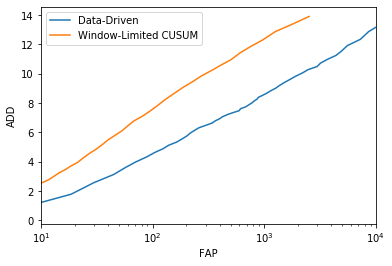

In [ ]:
plt.plot(fap_vec_minimax,add_vec_minimax)
plt.plot(wlc_fap_vec,wlc_add_vec)
plt.xlim(10,10000)
plt.xscale('log')
plt.xlabel('FAP')
plt.ylabel('ADD') 
plt.legend(["Data-Driven","Window-Limited CUSUM"]) 